# Credit Risk Project
## Exploratory Data Analysis

### Author: Aaron Thomas

**Goal**: The goal of this project is to analyze a dataset of credit risk and identify patterns and trends that can help predict the likelihood of default. 

## Table of Contents
<ol>
    <li><a href="#introduction">Introduction</a></li>
    <li><a href="#data-preprocessing">Data Preprocessing</a></li>
    <li><a href="#exploratory-data-analysis">Exploratory Data Analysis</a></li>
    <li><a href="#conclusion">Conclusion</a></li>
</ol>


## Introduction
The purpose of this project is to analyze a dataset of credit risk and identify patterns and trends that can help predict the likelihood of default. For this project, the following questions will be explored:
1. What is the overall default rate?
2. How does certain factors correlate with default risk?
3. Are there any differences in risk across loan purposes?
4. How does credit history affect default risk probability?

**Dataset**: The dataset used for this analysis is the LendingClub "Credit Risk Dataset" from Kaggle. The dataset can be found at the following link: <a href="https://www.kaggle.com/datasets/laotse/credit-risk-dataset">Credit Risk Dataset</a>

The dataset contains the following columns:
- person_age: The age of the borrower
- person_income: The income of the borrower
- person_home_ownership: The home ownership status of the borrower (e.g., RENT, OWN, MORTGAGE)
- person_emp_length: The length of employment of the borrower (in years)
- loan_intent: The purpose of the loan (e.g., EDUCATION, MEDICAL, PERSONAL)
- loan_grade: The grade of the loan (e.g., A, B, C)
- loan_amnt: The amount of the loan
- loan_int_rate: The interest rate of the loan
- loan_status: The status of the loan (e.g., 0 for non-default, 1 for default)
- loan_percent_income: The percentage of the borrower's income that the loan amount represents
- cb_person_default_on_file: Whether the borrower has a history of default (Y/N)
- cb_person_cred_hist_length: The length of the borrower's credit history (in years)


## Data Preprocessing

This section covers the steps taken to preprocess the data before performing exploratory data analysis.

### Load Data and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

df = pd.read_csv('C:\\Users\\astho\\Desktop\\credit-risk-model\\data\\credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Cleaning
This step involves checking for missing values and ensuring that the data types of each column are appropriate for analysis.

##### Check for missing values

In [2]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Looking at the results above, these observations can be made:
- `person_emp_length` has 895 missing values
- `loan_int_rate` has 3116 missing values

To address this, the following steps will be taken:
- For `person_emp_length`, the missing values will be filled with the median employment length.



In [3]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

C:\Users\astho\AppData\Local\Temp\ipykernel_36544\3490707621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)


Before addressing the `loan_int_rate` missing values, an additional analysis is performed. 

In [4]:
df.groupby('loan_status')['loan_int_rate'].mean()

loan_status
0    10.435999
1    13.060207
Name: loan_int_rate, dtype: float64

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

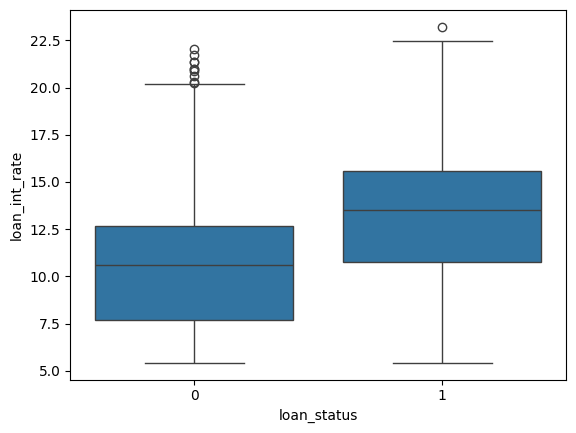

In [5]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)

Looking at the boxplot above, it is observed that:
- The default group (1) has a higher median interest rate compared to the non-default group (0). 
- Distribution is shifted upward for the default group, indicating that higher interest rates may be linked to higher default risk.


The next step is to see whether the missing interest rates are meaningful:

In [6]:
df.groupby(df['loan_int_rate'].isnull())['loan_status'].mean()


loan_int_rate
False    0.219379
True     0.206675
Name: loan_status, dtype: float64

Looking at the results above, the default rate for missing `loan_int_rate` values is slightly lower (20.67%) than the default rate for non-missing values (21.94%). In other words, missing interest rates seem to associate with a slightly lower default rate. 
To address the missing `loan_int_rate` values, imputation will be performed using a group-based median approach. This will consist of filling the missing values with the median interest rate for each loan grade, as interest rate is tied to loan grade (also credit risk). The following code is used to perform this imputation:

In [7]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

### Data Types

The purpose of this step is to check the data types of each column to ensure they are appropriate for analysis.

In [8]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
# Data types
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Looking at the data types, three features (`person_home_ownership`, `loan_intent`, and `cb_person_default_on_file`) are of object type, which indicates they are categorical variables. After EDA is completed, these features will be encoded using one-hot encoding to convert them into a format suitable for analysis. The remaining features are of numeric type, which is appropriate for analysis.

## Exploratory Data Analysis (EDA)

### Target Variable Analysis

The purpose of this analysis is to understand the distribution of the target variable, which is `loan_status` (0 for non-default, 1 for default).

#### Distribution of `loan_status`

A distribution analysis of `loan_status` is performed to understand and assess any imbalance in the target variable. The following code is used to calculate the distribution:

In [10]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [11]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

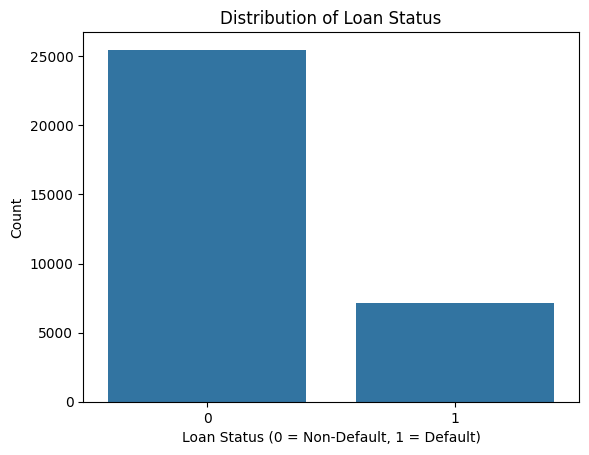

In [12]:
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

Looking at the proportions above, the dataset is imbalanced, with approximately 78% of loans being non-default (0) and 22% being default (1). In the later stages of this project, techniques to address this will be considered, such as resampling methods (e.g., SMOTE) or using algorithms that are considerate of class imbalance (e.g., XGBoost).

#### Default Rate

The default rate is calculated to understand the proportion of loans that have defaulted. The following code calculates the default rate:

In [13]:
default_rate = df['loan_status'].mean()
print('Default Rate: ', format(default_rate, '.2%'))

Default Rate:  21.82%


As shown, the default rate is approximately 21.82%, which represents the proportion of loans that have defaulted in the dataset. This information is crucial for understanding the overall risk level in the dataset and will be important for model evaluation later on.

### Univariate Analysis

The purpose of univariate analysis is to analyze each feature individually to understand its distribution and characteristics. This will help identify any patterns or trends that may be relevant for predicting default risk.

#### Distribution of Age

The distribution of age is analyzed to understand the age profile of borrowers and its potential impact on default risk. To start, the following code is utilized to see the unique values and their counts for the `person_age` feature:

In [14]:
# Unique values and counts for person_age
df['person_age'].value_counts().sort_index()


person_age
20       15
21     1229
22     3633
23     3889
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
49       49
50       52
51       39
52       36
53       30
54       24
55       20
56       15
57       15
58       19
59        5
60       15
61        9
62        7
63        3
64        7
65        9
66        9
67        1
69        5
70        7
73        3
76        1
78        1
80        1
84        1
94        1
123       2
144       3
Name: count, dtype: int64

As shown above, 5 values of `person_age` are either 123 or 144, which are likely data entry errors. These values will be removed from the dataset to ensure the accuracy of the analysis.

In [15]:
# Remove erroneous rows where age values of 123 and 144 are present
age_100_plus = df[df['person_age'] > 100].index
df.drop(age_100_plus, inplace=True)
df['person_age'].value_counts().sort_index()

person_age
20      15
21    1229
22    3633
23    3889
24    3549
25    3037
26    2477
27    2138
28    1854
29    1687
30    1316
31    1142
32     964
33     856
34     709
35     620
36     548
37     478
38     373
39     302
40     271
41     241
42     188
43     164
44     141
45     108
46      94
47      94
48      75
49      49
50      52
51      39
52      36
53      30
54      24
55      20
56      15
57      15
58      19
59       5
60      15
61       9
62       7
63       3
64       7
65       9
66       9
67       1
69       5
70       7
73       3
76       1
78       1
80       1
84       1
94       1
Name: count, dtype: int64

With the erroneous age values removed, the distribution of age can be analyzed further to understand the age profile of borrowers.

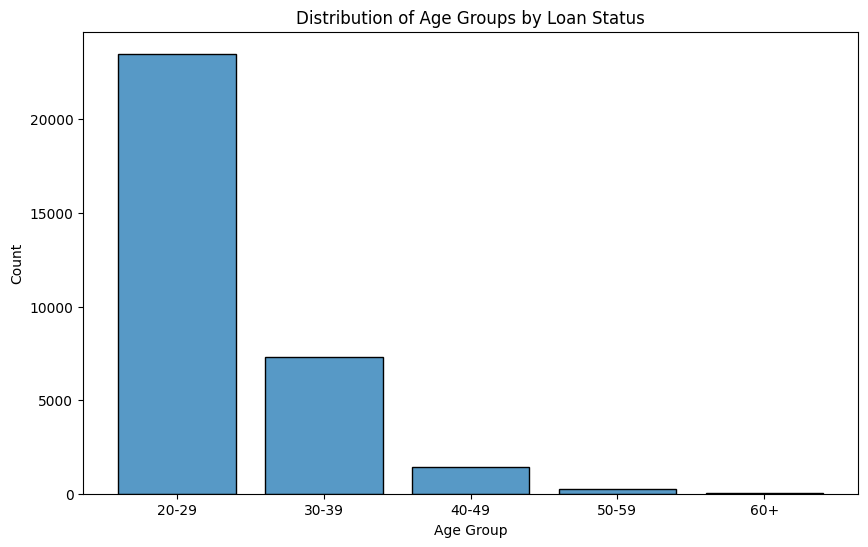

In [16]:
plt.figure(figsize=(10, 6))
age_bins = [20, 30, 40, 50, 60, 70]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60+']
df['age_group'] = pd.cut(df['person_age'], bins=age_bins, labels=age_labels, right=False)
sns.histplot(data=df, x = 'age_group', multiple='dodge', shrink=0.8)
plt.title('Distribution of Age Groups by Loan Status')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

Based on the histogram above, the following observations can be made:
- The majority of borrowers fall within the age group of 20-29.


#### Distribution of Income

The distribution of income is analyzed to understand the income profile of borrowers and its potential impact on default risk:

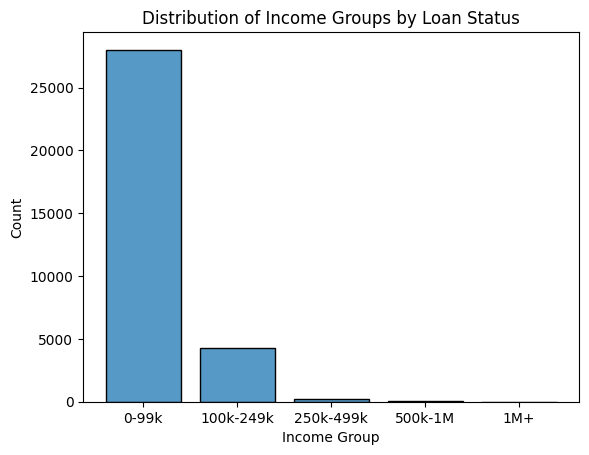

In [17]:
income_bins = [0, 100000, 250000, 500000, 750000,1000000]
income_labels = ['0-99k', '100k-249k', '250k-499k', '500k-1M', '1M+']
df['income_group'] = pd.cut(df['person_income'], bins=income_bins, labels=income_labels, right=False)
sns.histplot(data=df, x = 'income_group', multiple='dodge', shrink=0.8)
plt.title('Distribution of Income Groups by Loan Status')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.show()

Looking at the histogram above, the following observations can be made:
- The majority of borrowers fall within the income group of $0-$99k.

#### Loan-to-Income Ratio

The loan-to-income ratio is analyzed to understand how the loan amount compares to the borrower's income, which can be an important factor in assessing default risk. A high loan-to-income ratio may indicate that the borrower is taking on a loan larger than their income, increasing the likelihood of default. The code to analyze the distribution of loan-to-income ratio is shown below:

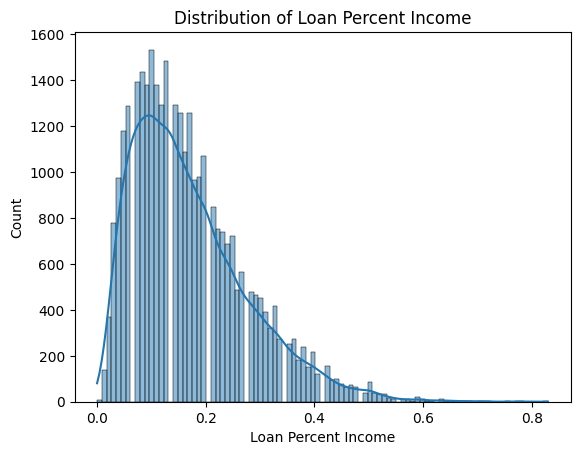

In [18]:
sns.histplot(df['loan_percent_income'], kde=True)
plt.title('Distribution of Loan Percent Income')
plt.xlabel('Loan Percent Income')
plt.show()

Based on the results above, the following observations can be made:
- The distribution is right-skewed, meaning that most borrowers have a low loan-to-income ratio.
- The majority of borrowers have a loan-to-income ratio below 0.25, indicating that they are taking on loans that are less than 25% of their income.

#### Loan Grade

The loan grade is analyzed to understand how the grade of the loan associates with default risk. Loan grades are typically assigned based on the creditworthiness of the borrower, with higher grades indicating lower risk. The following code is used to analyze the distribution of loan grades:

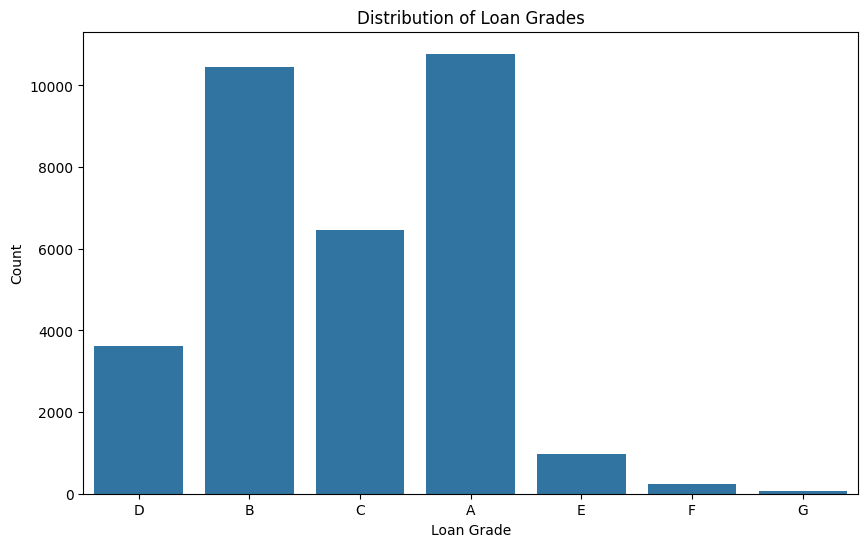

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='loan_grade', data=df)
plt.title('Distribution of Loan Grades')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()

Based on the results above, the following observations can be made:
- Loan grades A and B (the highest grades) have a higher proportion of loans compared to lower grades

#### Home Ownership

Home ownership is analyzed to understand how the borrower's home ownership status associates with default risk. It is also utilized to understand the distribution of home ownership among borrowers. The following code is used to analyze the distribution of home ownership:

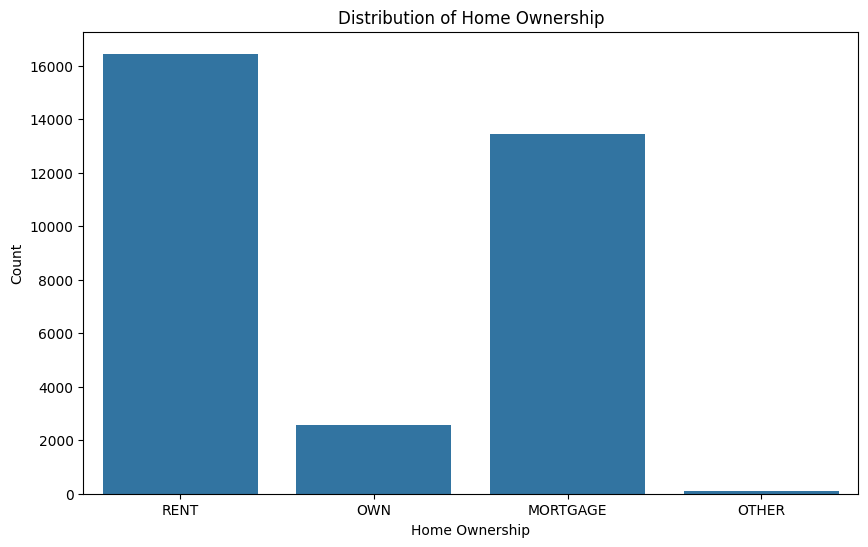

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='person_home_ownership', data=df)
plt.title('Distribution of Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

Based on the results above, the following observations can be made:
- Home ownership distribution shows that a large portion of borrowers are renters. 

### Bivariate Analysis

The purpose of bivariate analysis is to analyze the relationship between two variables. In this case, the relationship between certain features (e.g., home ownership) and the target variable (loan status) is analyzed to understand how these features associate with default risk.

#### Income vs Loan Status

In [21]:
df.groupby(pd.qcut(df['person_income'], 5))['loan_status'].mean()


C:\Users\astho\AppData\Local\Temp\ipykernel_36544\3314180885.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['person_income'], 5))['loan_status'].mean()


person_income
(3999.999, 35000.0]     0.432579
(35000.0, 49000.0]      0.234494
(49000.0, 63000.0]      0.181960
(63000.0, 86000.0]      0.145555
(86000.0, 2039784.0]    0.091371
Name: loan_status, dtype: float64

This part of the analysis is focused on trending the relationship between income and loan status. Looking at the results above, it seems that low income borrowers between $4k to $35k have a higher default rate compared to high income borrowers. 

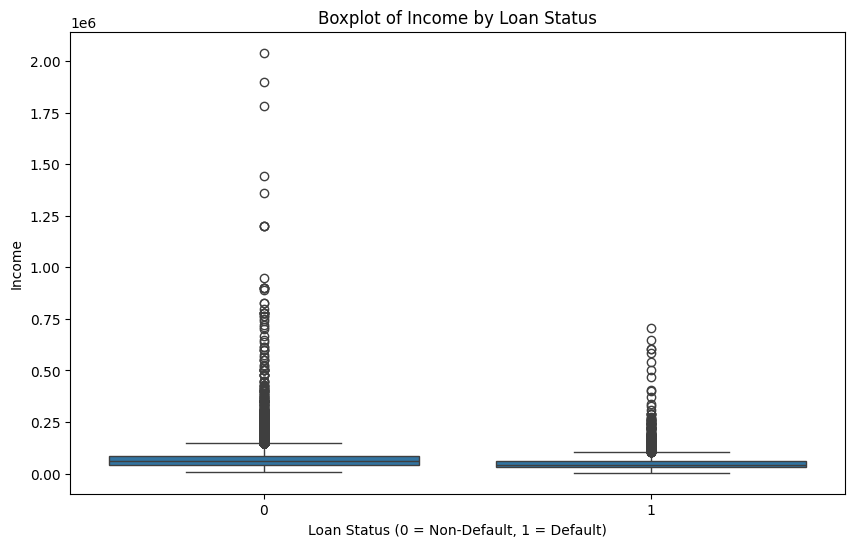

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Boxplot of Income by Loan Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Income')
plt.show()

Based on the results above, the following observations can be made:
- Borrowers who are default (loan_status = 1) tend to have a slightly lower median income compared to non-default borrowers (loan_status = 0).
- However, there seems to be a significant overlap in the income distribution of the two groups, indicating that income may not be a strong predictor of default risk on its own.



#### Loan Amount vs Loan Status

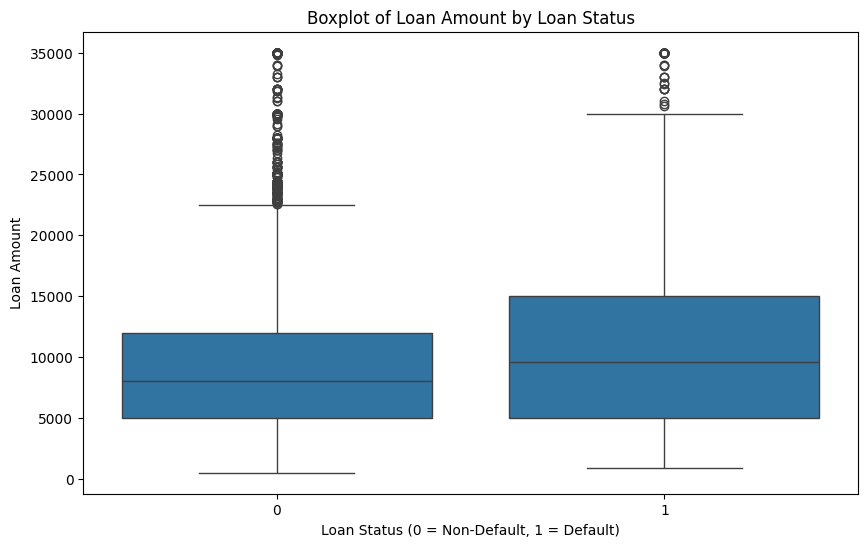

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Boxplot of Loan Amount by Loan Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Loan Amount')
plt.show()

Based on the results above, the following observations can be made:
- Borrowers who are in the default group (loan_status = 1) tend to have a higher median loan amount.
- Overall, it appears that higher loan amounts may have stronger associations with default risk.

#### Loan-To-Income Ratio vs Loan Status

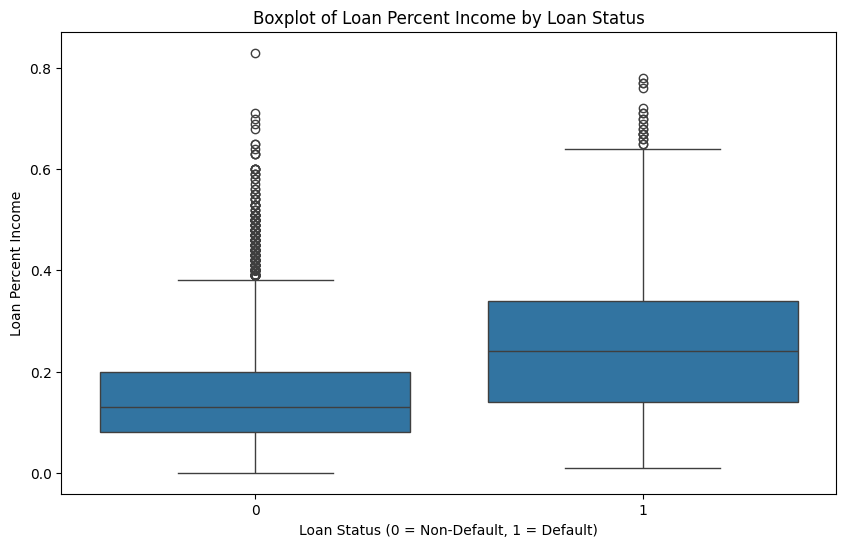

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title('Boxplot of Loan Percent Income by Loan Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Loan Percent Income')
plt.show()

Based on the results above, the following observations can be made:
- Borrowers who are default (loan_status = 1) have higher median loan-to-income ratios.
- This appears to suggest that borrowers with higher loan-to-income ratios are at higher risk of default.


#### Loan Purpose vs Loan Status

In [25]:
df.groupby('loan_intent')['loan_status'].mean().sort_values()

loan_intent
VENTURE              0.148155
EDUCATION            0.172221
PERSONAL             0.198913
HOMEIMPROVEMENT      0.261026
MEDICAL              0.267007
DEBTCONSOLIDATION    0.285879
Name: loan_status, dtype: float64

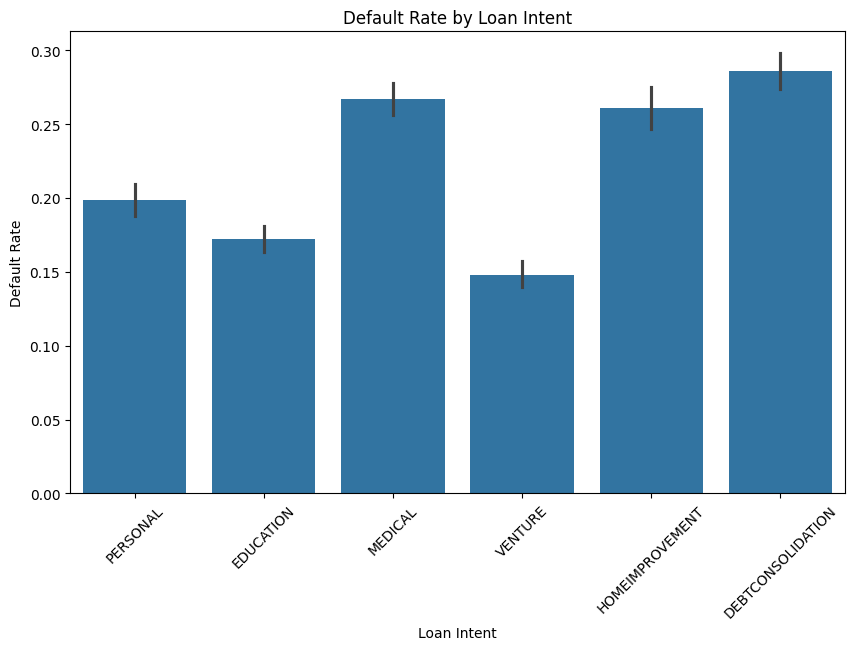

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='loan_intent', y='loan_status', data=df)
plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

Based on the results above, the following observations can be made:
- Loans taken out for debt consolidation have a higher proportion of default rate, meaning that borrowers who take out loans for debt consolidation may be at higher risk of default.

#### Loan Grade vs Loan Status

In [27]:
df.groupby('loan_grade')['loan_status'].mean().sort_values()

loan_grade
A    0.099564
B    0.162806
C    0.207404
D    0.590458
E    0.644191
F    0.705394
G    0.984375
Name: loan_status, dtype: float64

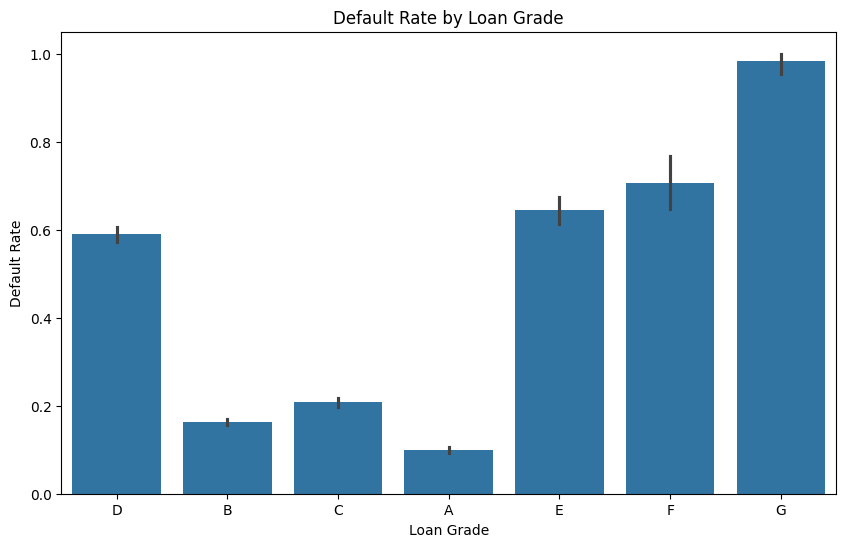

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='loan_grade', y='loan_status', data=df)
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.show()


Based on the results above, the following observations can be made:
- Borrowers with loan grade G (the lowest grade) have the highest proportion of default loans, followed by those with loan grade F.
- Borrowers with loan grades A and B (the highest grades) have the lowest proportion of default loans, indicating that loan grade is a strong predictor of default risk.

#### Prior Default History vs Loan Status

In [29]:
df.groupby('cb_person_default_on_file')['loan_status'].mean().sort_values()

cb_person_default_on_file
N    0.183966
Y    0.378068
Name: loan_status, dtype: float64

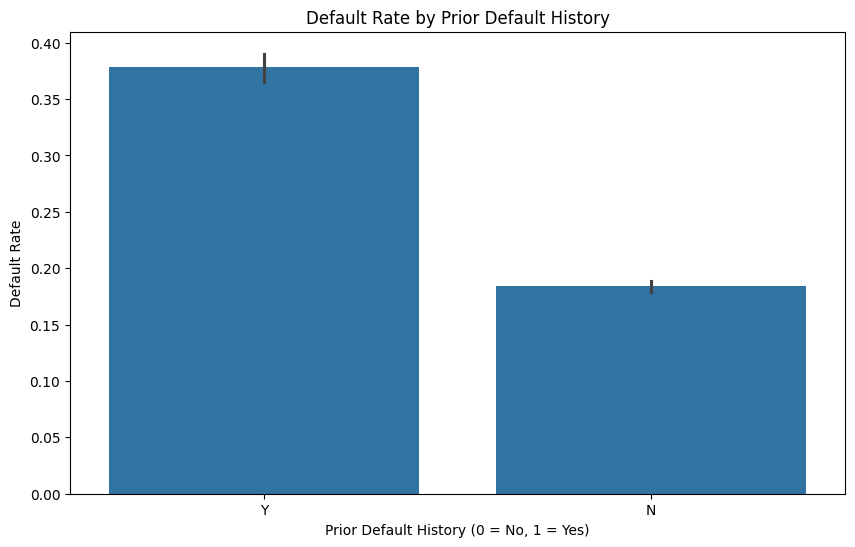

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cb_person_default_on_file', y='loan_status', data=df)
plt.title('Default Rate by Prior Default History')
plt.xlabel('Prior Default History (0 = No, 1 = Yes)')
plt.ylabel('Default Rate')
plt.show()

Based on the results above, the following observations can be made:
- Borrowers with prior default history (`cb_person_default_on_file` = 1) have a higher default rate compared to those without prior default history.
- This suggests that prior default history is a significant indicator of default risk, meaning that borrowers with a history of default are more likely to default again.

### Multivariate Analysis

The purpose of multivariate analysis is to analyze the relationship between multiple variables simultaneously. This can help uncover complex patterns and interactions that may influence default risk.

#### Correlation Matrix

The correlation matrix is utilized to analyze the relationships between multiple numeric variables simultaneously. It helps identify which features are strongly associated with each other and with the target variable (loan_status). The following code is used to create a correlation matrix:

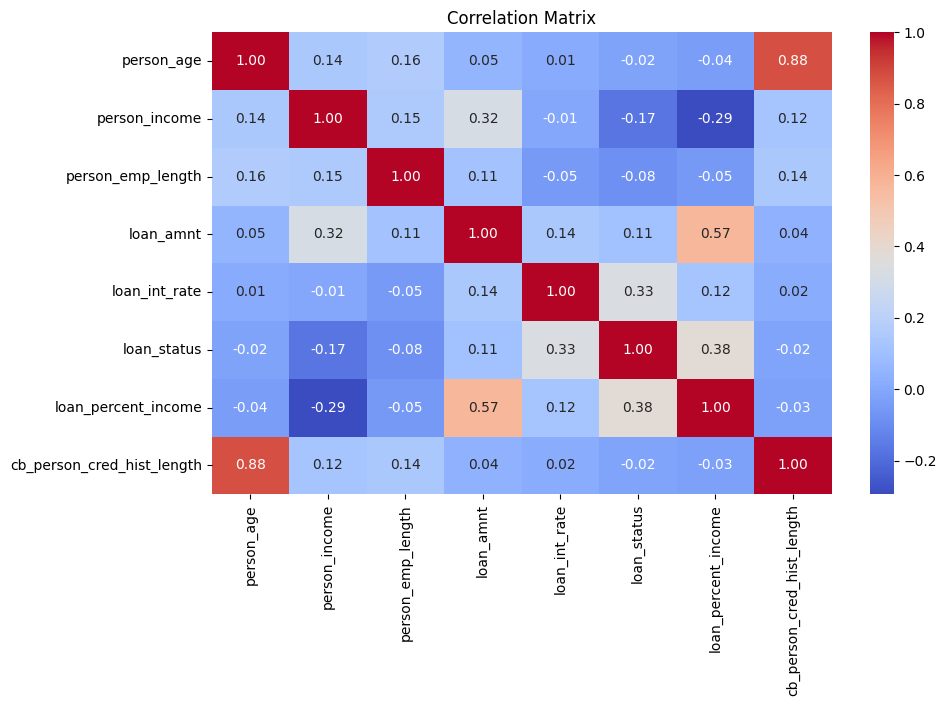

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Based on the matrix above, the following observations can be made:
- `loan_status` has a weak positive correlation with `loan_int_rate` (0.33), indicating that higher 

#### Correlation Matrix - Loan Status and Loan Grade

A further analysis of the correlation matrix will be perfomed between `loan_status` and other features to identify any additional relationships that may be relevant for predicting default risk.

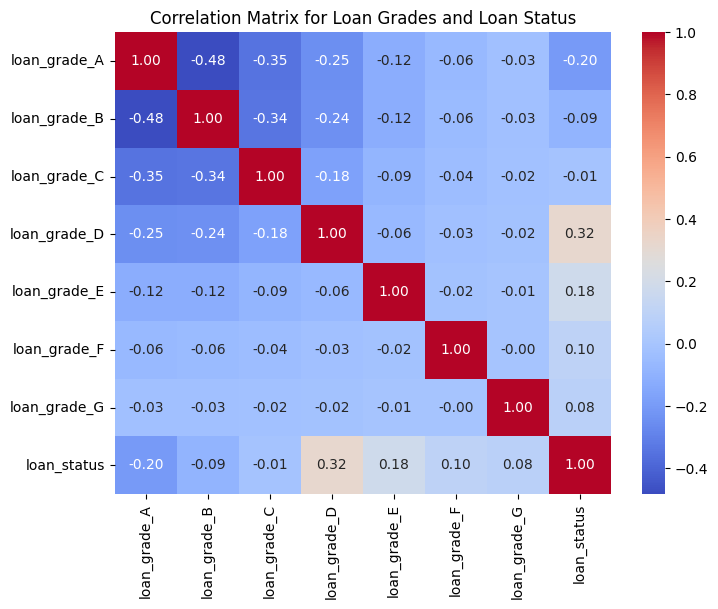

In [32]:
# Create dummy variables for loan grades
df = df.assign(loan_grade_A = (df['loan_grade'] == 'A').astype(int))
df = df.assign(loan_grade_B = (df['loan_grade'] == 'B').astype(int))
df = df.assign(loan_grade_C = (df['loan_grade'] == 'C').astype(int))
df = df.assign(loan_grade_D = (df['loan_grade'] == 'D').astype(int))
df = df.assign(loan_grade_E = (df['loan_grade'] == 'E').astype(int))
df = df.assign(loan_grade_F = (df['loan_grade'] == 'F').astype(int))
df = df.assign(loan_grade_G = (df['loan_grade'] == 'G').astype(int))
# Create correlation matrix for loan grades and loan status
loan_grade_corr = df[['loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'loan_status']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(loan_grade_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Loan Grades and Loan Status')
plt.show()


Based on the results above, the following observations can be made:
- `loan_status` has a weak positive correlation with `loan_grade_D` (0.32), indicating that borrowers with loan grade D could be at risk of default, but by a small margin.

#### Income vs Loan Percent Income By Loan Default Status

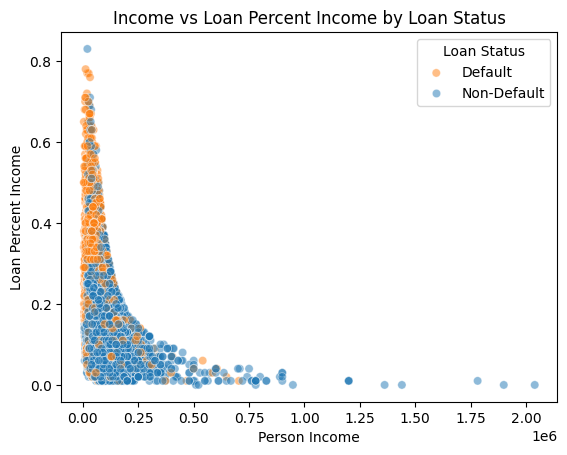

In [44]:
sns.scatterplot(
    x = 'person_income',
    y = 'loan_percent_income',
    hue = 'loan_status', # Color points by loan status (default vs non-default)
    data=df,
    alpha=0.5 # Add transparency to points for better visibility
)
plt.title('Income vs Loan Percent Income by Loan Status')
plt.xlabel('Person Income')
plt.ylabel('Loan Percent Income')
plt.legend(title='Loan Status', labels=['Default', 'Non-Default'])
plt.show()

Based on the results above, the following observations can be made:
- There is a strong relationship between income and loan percent income; as income increases, the loan percent income decreases.
- High income borrowers tend to have lower loan percent income, indicating that they may take on smaller loans.

#### Loan Burden vs Loan Default Status

In [34]:
df.groupby(pd.qcut(df['loan_percent_income'], 5))['loan_status'].mean()

C:\Users\astho\AppData\Local\Temp\ipykernel_36544\1292938688.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['loan_percent_income'], 5))['loan_status'].mean()


loan_percent_income
(-0.001, 0.08]    0.114150
(0.08, 0.12]      0.124597
(0.12, 0.18]      0.151709
(0.18, 0.25]      0.191412
(0.25, 0.83]      0.529384
Name: loan_status, dtype: float64

Looking at the results above, the following observations can be made:
- Borrowers with higher loan-to-income ratios (0.25 - 0.8) have a higher default rate, indicating that there is a significant relationship between loan burden and default risk.

#### Past Default vs Loan Burden

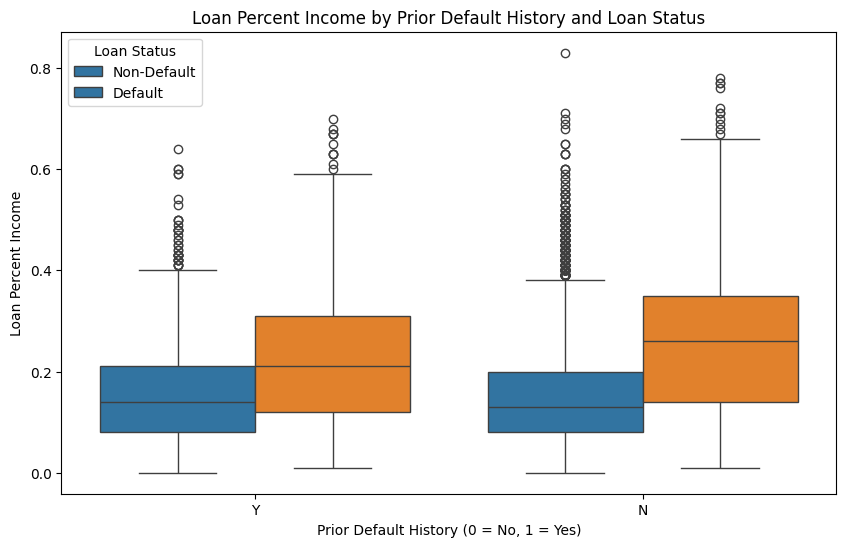

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cb_person_default_on_file', y='loan_percent_income', hue='loan_status', data=df)
plt.title('Loan Percent Income by Prior Default History and Loan Status')
plt.xlabel('Prior Default History (0 = No, 1 = Yes)')
plt.ylabel('Loan Percent Income')
label_map = {0: 'Non-Default', 1: 'Default'}
plt.legend(title='Loan Status', labels=label_map.values())
plt.show()

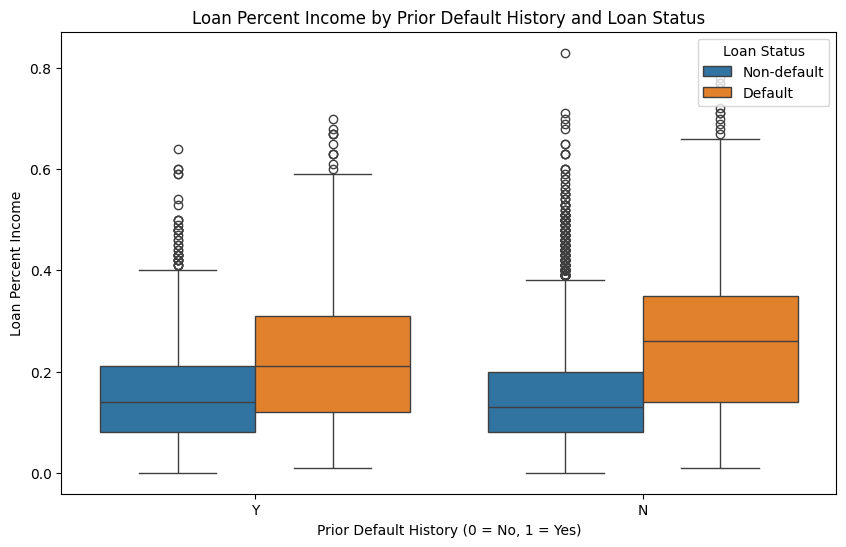

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='cb_person_default_on_file', y='loan_percent_income', hue='loan_status', data=df)
plt.title('Loan Percent Income by Prior Default History and Loan Status')
plt.xlabel('Prior Default History (0 = No, 1 = Yes)')
plt.ylabel('Loan Percent Income')
handles, labels = ax.get_legend_handles_labels()
label_map = {'0': 'Non-default', '1': 'Default'}
new_labels = [label_map.get(str(lbl), str(lbl)) for lbl in labels]
ax.legend(handles=handles, labels=new_labels, title='Loan Status', loc='upper right')
plt.show()

Based on the results above, the following observations can be made:
- Higher loan percent income is linked to higher default risk, especially for borrowers with a history of default. 
- Prior default history increases the likelihood of another default, particularly for those with higher loan burdens.
- Loan percent income is a strong predictor of default risk, especially when combined with prior default history. 

## Conclusion

The purpose of this project was to explore the key factors that contribute to loan default risk through exploratory data analysis. 

### Key Findings:

- Borrowers with higher loan-to-income ratios are at a significantly higher risk of default, especially if they have a history of prior default.
- Loan grade is a strong predictor of default risk, with lower grades (e.g., G and F) being associated with higher default rates.
- Borrowers with prior default history are more likely to default again.
- While income alone is not a strong predictor of default risk, it is important to consider it in conjunction with other factors such as loan amount and loan-to-income ratio for a more comprehensive assessment of default risk.

### Business Implications

The findings from EDA suggest that lenders should primarily focus on evaluating the borrower's debt burden and credit history when assessing loan applications. Borrowers with high loan-to-income ratios and prior history of defaults may require stricter approval criteria or adjusted loan terms to mitigate potential losses. 

### Next Steps

Future work will involve building predictive models (e.g. logistic regression, random forest, etc.) to predict loan default risk and evaluate model performance using metrics such as accuracy, precision, recall, and F1-score. 